In [8]:
# TomTom Excel files — all files are combined into a single dataset.
INPUT_FILES = [
    r"C:\Users\IvanVelilla\Mobility Lab Limited\Projects - 1034 - Western LX Aimsun\New North Road\Model\v10\Resources\Real Data Sets\jobs_8175988_results_New_North_Road.xlsx",
    r"C:\Users\IvanVelilla\Mobility Lab Limited\Projects - 1034 - Western LX Aimsun\New North Road\Model\v10\Resources\Real Data Sets\jobs_9085074_results_New_North_Road_Extension_-_Western_LX.xlsx",
]

# Path to the Aimsun SQLite output database
SQLITE_FILE = r"C:\Users\IvanVelilla\Mobility Lab Limited\Projects - 1034 - Western LX Aimsun\New North Road\Model\v10\Resources\Outputs\ADTA_NNR_WesternLX_v10.sqlite"
# SQLITE_FILE = r"C:\Users\IvanVelilla\Downloads\ADTA_NNR_v10.sqlite"

# Output CSV path (set to None to skip saving)
OUTPUT_CSV = 'outputs/obs_travel_times.csv'

# MISUBPATH filters (set to None or [] to load all)
MISUBPATH_FILTERS = {
    "did": [89336353, 89336930],  # Average Base AM + Average Base PM
    "oid": [89336741, 89336739, 89336740, 89336752, 89336753, 89336744, 89336746, 89361021, 89361022, 89336754, 89336755, 89336747, 89336749, 89336750, 89336751, 89362303, 89362304],
    "sid": [0],
    "eid": None,
}

# Map Aimsun subpath oid → route name (must match TomTom route names exactly).
# Values must be plain strings — do not use lists.
OID_ROUTE_MAP = {
    89336741: "Blockhouse Bay Rd NB",
    89336739: "New North Road NB",
    89336740: "New North Road SB",
    89336752: "Morningside NB",
    89336753: "Morningside SB",
    89336746: "Richardson Road EB",
    89336744: "Richardson Road WB",
    89361021: "Saint Georges Road NB",
    89361022: "Saint Georges Road SB",
    89336754: "Sandringham NB",
    89336755: "Sandringham SB",
    89336747: "Mount Albert Rd EB",
    89336749: "Mount Albert Rd WB",
    89336750: "St Lukes Rd EB",
    89336751: "St Lukes Rd WB",
    89362303: "Great North Road EB",
    89362304: "Great North Road WB",
}

# Time periods to keep — rows whose time window does not match any period are dropped
import pandas as pd
import datetime

output_hours_config = pd.DataFrame([
    {"period": "AM2", "start_time": datetime.time(7, 0),  "end_time": datetime.time(8, 0)},
    {"period": "AM3", "start_time": datetime.time(8, 0),  "end_time": datetime.time(9, 0)},
    {"period": "PM2", "start_time": datetime.time(16, 0), "end_time": datetime.time(17, 0)},
    {"period": "PM3", "start_time": datetime.time(17, 0), "end_time": datetime.time(18, 0)},
])

In [2]:
import re
import sys
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
sys.path.insert(0, r"C:\Users\IvanVelilla\Documents\Projects\Western LX\src")

from obs_utils import (
    extract_route_percentiles_each_segment,
    import_tomtom_data_average,
    calculate_travel_time,
    reformat_tomtom_data,
)

plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 120,
})

print("Ready.")

Ready.


In [3]:
# Run this cell first to see which routes are available across all input files
import re

def _route_names_from_file(path):
    xlsx = pd.ExcelFile(path)
    pct_sheets = [s for s in xlsx.sheet_names if s.endswith("-PercentilesEachSegment")]
    avg_sheets = [s for s in xlsx.sheet_names if s.endswith("-CumulativeTravelTimes")]
    def _name(sheet, pattern):
        raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=1)
        return re.sub(pattern, "", str(raw.iloc[0, 0])).strip()
    return (
        {_name(s, r"^Speed percentiles for each segment\s*") for s in pct_sheets}
        | {_name(s, r"^Cumulative Travel time along route\s*") for s in avg_sheets}
    )

available_routes = sorted(set().union(*[_route_names_from_file(p) for p in INPUT_FILES]))

print(f"Found {len(available_routes)} route(s) across {len(INPUT_FILES)} file(s):")
for r in available_routes:
    print(f"  {r}")

c:\Users\IvanVelilla\Documents\Projects\Western LX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\IvanVelilla\Documents\Projects\Western LX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\IvanVelilla\Documents\Projects\Western LX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\IvanVelilla\Documents\Projects\Western LX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply o

Found 17 route(s) across 2 file(s):
  Blockhouse Bay Rd NB
  Great North Road EB
  Great North Road WB
  Morningside NB
  Morningside SB
  Mount Albert Rd EB
  Mount Albert Rd WB
  New North Road NB
  New North Road SB
  Richardson Road EB
  Richardson Road WB
  Saint Georges Road NB
  Saint Georges Road SB
  Sandringham NB
  Sandringham SB
  St Lukes Rd EB
  St Lukes Rd WB


In [4]:
# Routes to process. Copy names from the cell above.
# Leave empty to import all routes.
SELECTED_ROUTES = []

In [5]:
routes_to_use = SELECTED_ROUTES if SELECTED_ROUTES else available_routes
print(f"Processing {len(routes_to_use)} route(s) from {len(INPUT_FILES)} file(s)")

output_hours_config["Time"] = (
    output_hours_config["start_time"].apply(lambda t: f"{t.hour}:{t.minute:02d}")
    + "-"
    + output_hours_config["end_time"].apply(lambda t: f"{t.hour}:{t.minute:02d}")
)

def _process_file(path, routes):
    extracted = extract_route_percentiles_each_segment(path)
    extracted = extracted[extracted["Route"].isin(routes)]
    processed = calculate_travel_time(extracted)
    reformatted = reformat_tomtom_data(processed)
    average = import_tomtom_data_average(path)
    average = average[average["route"].isin(routes)]
    df = pd.concat([reformatted, average], ignore_index=True)
    df = df.merge(output_hours_config[["period", "Time"]], on="Time", how="left")
    df = df.rename(columns={"period": "hour"}).drop(columns=["Time"])
    df = df[df["hour"].notna()]
    df["average_ttime"] = df["average_ttime"] / 60
    return df

all_dfs = [_process_file(p, routes_to_use) for p in INPUT_FILES]
combined_df = pd.concat(all_dfs, ignore_index=True)

print(f"\nFinal dataset: {len(combined_df)} rows")
combined_df.head()

Processing 17 route(s) from 2 file(s)


c:\Users\IvanVelilla\Documents\Projects\Western LX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\IvanVelilla\Documents\Projects\Western LX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\IvanVelilla\Documents\Projects\Western LX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\IvanVelilla\Documents\Projects\Western LX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply o


Final dataset: 14944 rows


,cumulative_distance,route,average_ttime,scenario_name,year,year_scenario,vehicle_type,hour
0,0,Blockhouse Bay Rd NB,0.000000,obs_15th,2025,2025 obs_15th,All Vehicles,PM2
1,26.69,Blockhouse Bay Rd NB,0.039059,obs_15th,2025,2025 obs_15th,All Vehicles,PM2
2,41.35,Blockhouse Bay Rd NB,0.059049,obs_15th,2025,2025 obs_15th,All Vehicles,PM2
3,63.74,Blockhouse Bay Rd NB,0.088903,obs_15th,2025,2025 obs_15th,All Vehicles,PM2
4,112.38,Blockhouse Bay Rd NB,0.150996,obs_15th,2025,2025 obs_15th,All Vehicles,PM2


In [6]:
def load_misubpath(sqlite_path, filters=None):
    filters = filters or {}

    conditions, params = [], []
    for col in ("did", "oid", "sid", "eid"):
        values = filters.get(col)
        if values:
            placeholders = ", ".join("?" * len(values))
            conditions.append(f"{col} IN ({placeholders})")
            params.extend(values)

    where = f"WHERE {' AND '.join(conditions)}" if conditions else ""

    con = sqlite3.connect(sqlite_path)
    misubpath = pd.read_sql(
        f"SELECT did, oid, eid AS subpath_name, sid, ent, "
        f"count, flow, speed, ttime, dtime, wtimeVQ, traveltime, stime, nstops, "
        f"CASE WHEN count > 0 THEN travel / count ELSE NULL END AS distance "
        f"FROM MISUBPATH {where}",
        con, params=params,
    )
    sim_info = pd.read_sql(
        "SELECT did, didname, xname AS experiment, scname AS scenario, "
        "from_time, duration, type FROM SIM_INFO",
        con,
    )
    con.close()

    df = misubpath.merge(sim_info, on="did", how="left")
    df.replace(-1.0, np.nan, inplace=True)

    for col in ["ttime", "dtime", "stime", "traveltime"]:
        if col in df.columns:
            df[f"{col}_min"] = df[col] / 60

    return df

misubpath_df = load_misubpath(SQLITE_FILE, filters=MISUBPATH_FILTERS)

print(f"MISUBPATH: {len(misubpath_df):,} rows")
print(f"Subpath names: {misubpath_df['subpath_name'].unique().tolist()}")
print(f"Experiments:   {misubpath_df['experiment'].unique().tolist()}")
print(f"Simulation types: {misubpath_df['type'].unique().tolist()}  (1=replication, 2=average)")
print(f"\nColumns: {misubpath_df.columns.tolist()}")
misubpath_df.head(20)

MISUBPATH: 578 rows
Subpath names: ['2025 Base']
Experiments:   ['2025 Base AM', '2025 Base PM']
Simulation types: [2]  (1=replication, 2=average)

Columns: ['did', 'oid', 'subpath_name', 'sid', 'ent', 'count', 'flow', 'speed', 'ttime', 'dtime', 'wtimeVQ', 'traveltime', 'stime', 'nstops', 'distance', 'didname', 'experiment', 'scenario', 'from_time', 'duration', 'type', 'ttime_min', 'dtime_min', 'stime_min', 'traveltime_min']


,did,oid,subpath_name,sid,ent,count,flow,speed,ttime,dtime,...,didname,experiment,scenario,from_time,duration,type,ttime_min,dtime_min,stime_min,traveltime_min
0,89336353,89336739,2025 Base,0,0,56.1,14.025,23.099878,989.453115,497.746022,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,16.490885,8.295767,6.969554,925.138663
1,89336353,89336739,2025 Base,0,1,1.2,4.800,34.397424,651.705420,160.007847,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,10.861757,2.666797,1.988889,13.034108
2,89336353,89336739,2025 Base,0,10,5.6,22.400,19.347026,1154.279268,662.539827,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,19.237988,11.042330,9.549524,107.732732
3,89336353,89336739,2025 Base,0,11,4.4,17.600,19.141121,1170.429836,678.672040,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,19.507164,11.311201,9.783636,85.831521
4,89336353,89336739,2025 Base,0,12,3.8,15.200,20.184562,1115.375401,623.633233,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,18.589590,10.393887,8.952982,70.640442
5,89336353,89336739,2025 Base,0,13,3.9,15.600,21.865688,1020.699897,529.006402,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,17.011665,8.816773,7.413675,66.345493
6,89336353,89336739,2025 Base,0,14,2.9,11.600,21.839307,1022.739483,531.080054,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,17.045658,8.851334,7.245057,49.432408
7,89336353,89336739,2025 Base,0,15,3.1,12.400,23.409688,959.081231,467.413504,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,15.984687,7.790225,6.367742,49.552530
8,89336353,89336739,2025 Base,0,16,2.2,8.800,26.810184,830.939489,339.295156,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,13.848991,5.654919,4.521212,30.467781
9,89336353,89336739,2025 Base,0,2,1.4,5.600,34.160820,652.870641,161.223563,...,Average Base AM,2025 Base AM,2025 Base AM,21600,14400,2,10.881177,2.687059,1.974286,15.233648


In [9]:
# Count-weighted average travel time per oid and hour from Aimsun MISUBPATH.
# Each oid is one complete route. The result is one row per (oid, hour):
#   weighted_ttime_min — count-weighted average travel time for the route
#   simple_ttime_min   — simple (unweighted) mean of interval travel times
#   route_dist_km      — average route length (distance = travel/count, computed in SQL)

INTERVAL_DUR_S = 900  # 15 minutes

df_w = misubpath_df[misubpath_df["ent"] > 0].copy()
df_w["interval_start_s"] = df_w["from_time"] + (df_w["ent"] - 1) * INTERVAL_DUR_S

def map_period(start_s):
    for _, row in output_hours_config.iterrows():
        p_start = row["start_time"].hour * 3600 + row["start_time"].minute * 60
        p_end   = row["end_time"].hour   * 3600 + row["end_time"].minute   * 60
        if p_start <= start_s < p_end:
            return row["period"]
    return None

df_w["hour"] = df_w["interval_start_s"].apply(map_period)
df_w = df_w[df_w["hour"].notna() & df_w["ttime"].notna() & df_w["count"].notna() & (df_w["count"] > 0)].copy()

df_w["ttime_x_count"] = df_w["ttime"] * df_w["count"]

aimsun_weighted = (
    df_w.groupby(["oid", "hour", "subpath_name"])
    .agg(
        ttime_x_count_sum=("ttime_x_count", "sum"),
        count_sum=("count", "sum"),
        ttime_mean=("ttime", "mean"),
        route_dist_km=("distance", "mean"),
        total_count=("count", "sum"),
    )
    .reset_index()
)

aimsun_weighted["weighted_ttime_s"]   = aimsun_weighted["ttime_x_count_sum"] / aimsun_weighted["count_sum"]
aimsun_weighted["weighted_ttime_min"] = aimsun_weighted["weighted_ttime_s"] / 60
aimsun_weighted["simple_ttime_min"]   = aimsun_weighted["ttime_mean"] / 60
aimsun_weighted["route_dist_m"]       = aimsun_weighted["route_dist_km"] * 1000
aimsun_weighted = aimsun_weighted.drop(columns=["ttime_x_count_sum", "count_sum", "ttime_mean"])

# Normalise OID_ROUTE_MAP values to plain strings (guard against accidental list entries)
_route_map = {k: (v[0] if isinstance(v, list) else v) for k, v in OID_ROUTE_MAP.items()}
aimsun_weighted["route"] = aimsun_weighted["oid"].map(_route_map)

print(f"Aimsun weighted travel times: {len(aimsun_weighted)} rows")
print(f"Hours covered:   {sorted(aimsun_weighted['hour'].unique())}")
print(f"Subpath names:   {sorted(aimsun_weighted['subpath_name'].unique())}")
aimsun_weighted.head(20)

Aimsun weighted travel times: 66 rows
Hours covered:   ['AM2', 'AM3', 'PM2', 'PM3']
Subpath names:   ['2025 Base']


,oid,hour,subpath_name,route_dist_km,total_count,weighted_ttime_s,weighted_ttime_min,simple_ttime_min,route_dist_m,route
0,89336739,AM2,2025 Base,6.149950,17.50,974.406435,16.240107,16.352350,6149.949629,New North Road NB
1,89336739,AM3,2025 Base,6.150038,18.70,1119.982062,18.666368,18.663093,6150.037766,New North Road NB
2,89336739,PM2,2025 Base,6.149839,10.50,884.947887,14.749131,14.713051,6149.839451,New North Road NB
3,89336739,PM3,2025 Base,6.150826,13.00,958.206708,15.970112,16.061553,6150.826250,New North Road NB
4,89336740,PM2,2025 Base,6.148623,92.75,907.802245,15.130037,15.087718,6148.623227,New North Road SB
5,89336740,PM3,2025 Base,6.148798,106.50,1158.865711,19.314429,19.163000,6148.798463,New North Road SB
6,89336741,AM2,2025 Base,0.722568,154.10,171.816164,2.863603,2.868768,722.568268,Blockhouse Bay Rd NB
7,89336741,AM3,2025 Base,0.722573,153.50,199.492224,3.324870,3.344210,722.572567,Blockhouse Bay Rd NB
8,89336741,PM2,2025 Base,0.722565,171.25,124.317446,2.071957,2.071639,722.565427,Blockhouse Bay Rd NB
9,89336741,PM3,2025 Base,0.722540,164.75,132.903512,2.215059,2.206459,722.540385,Blockhouse Bay Rd NB


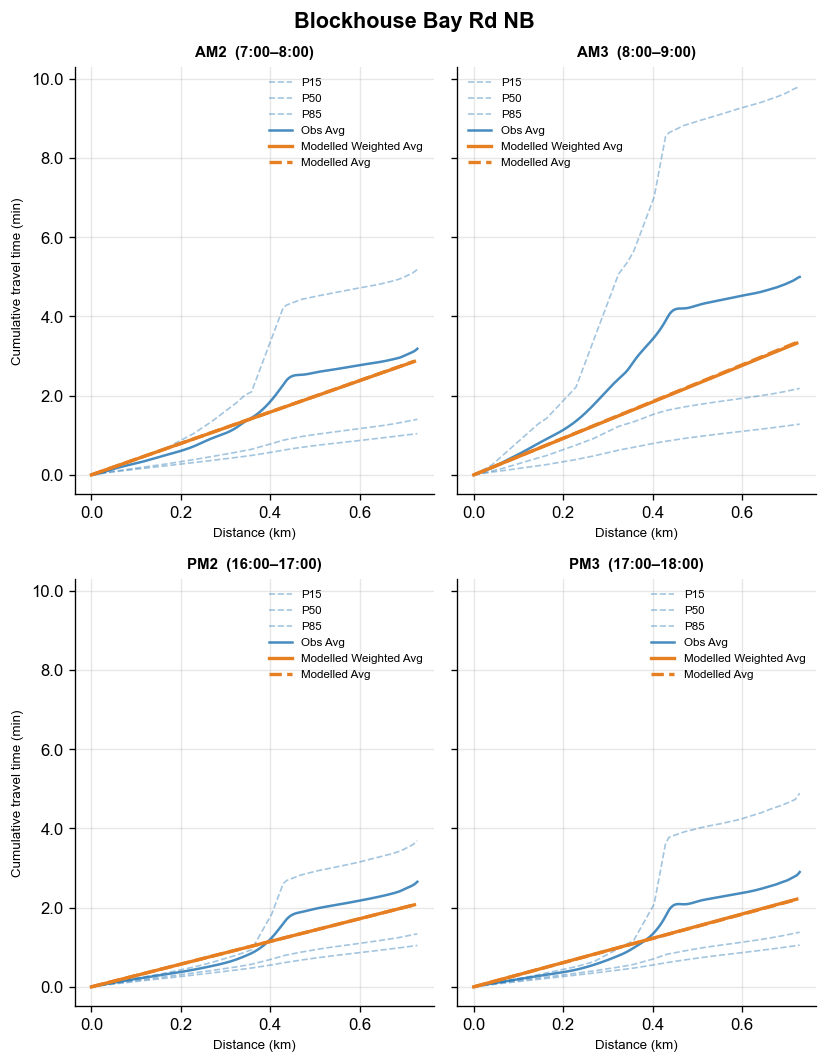

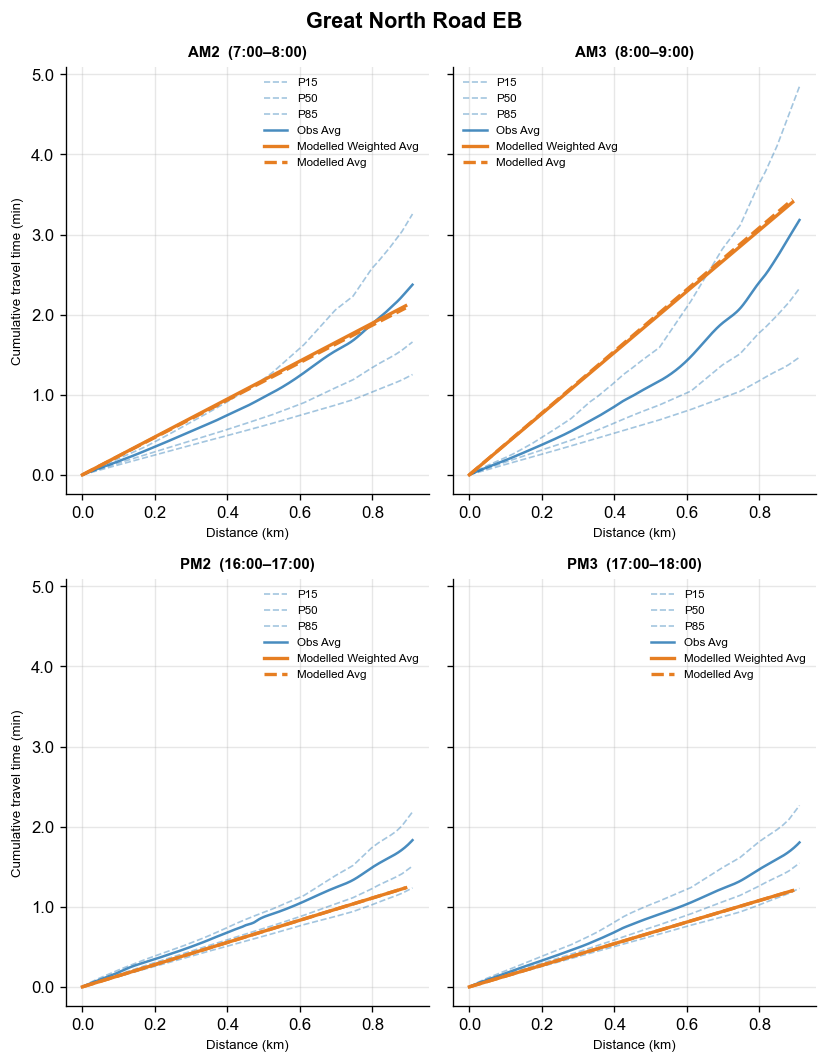

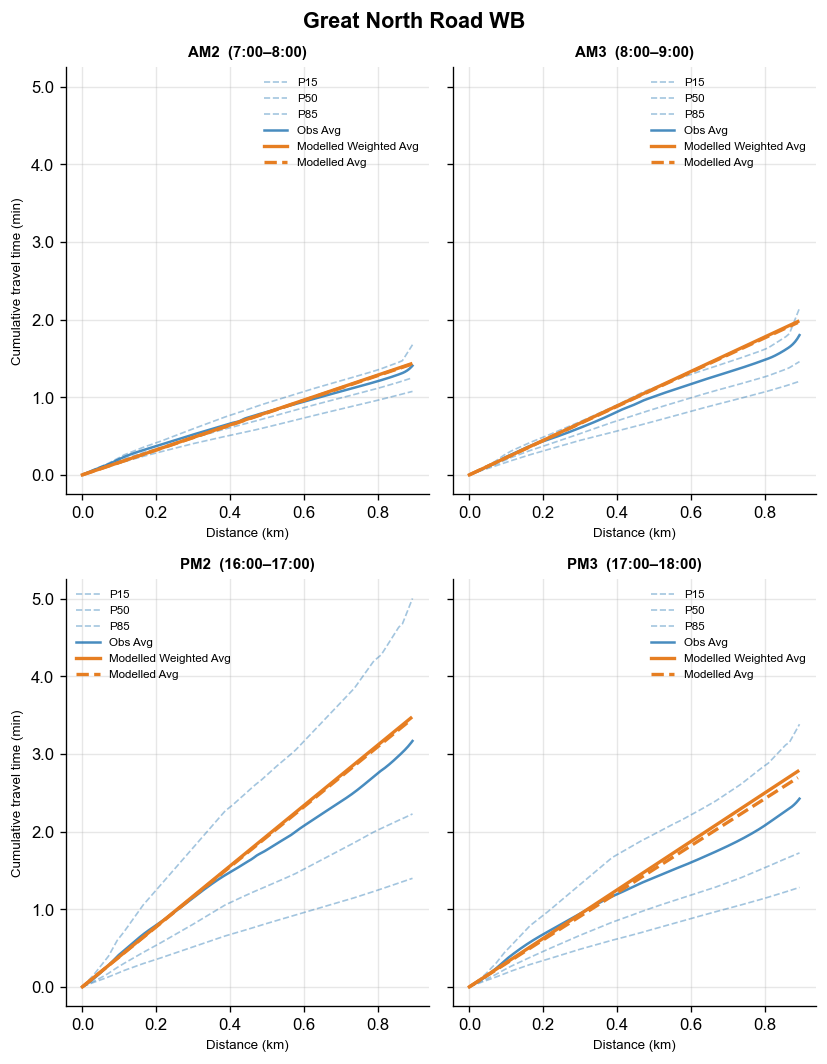

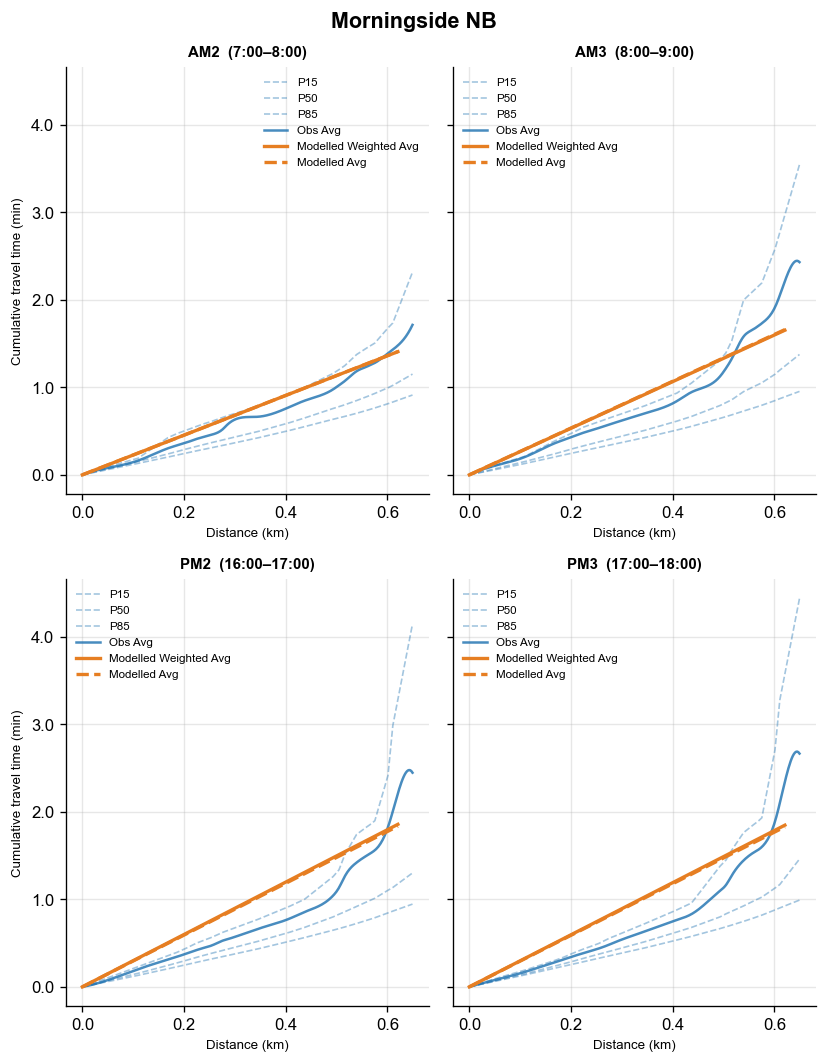

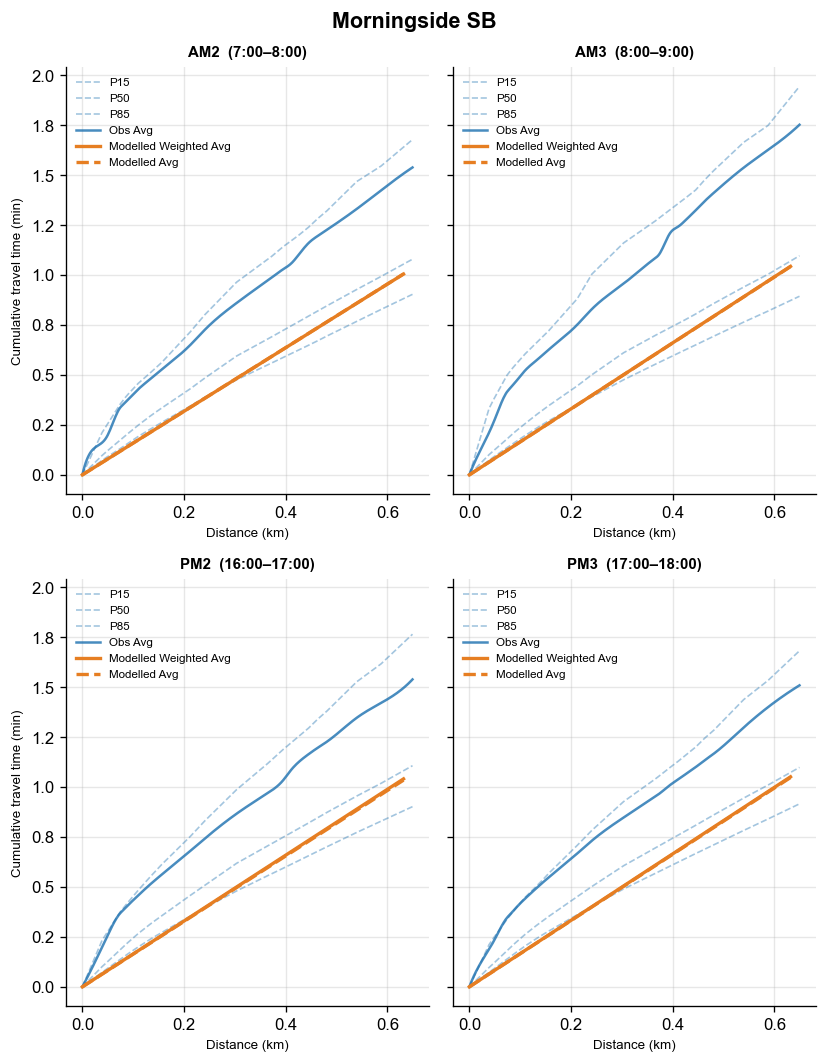

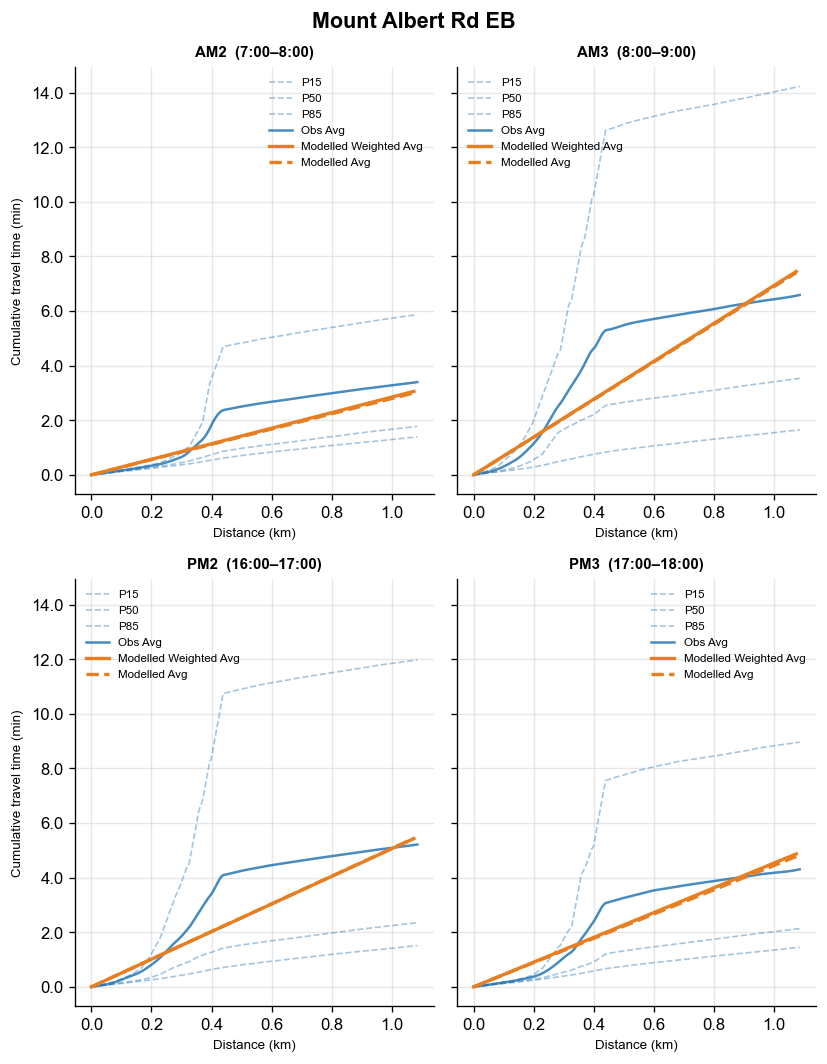

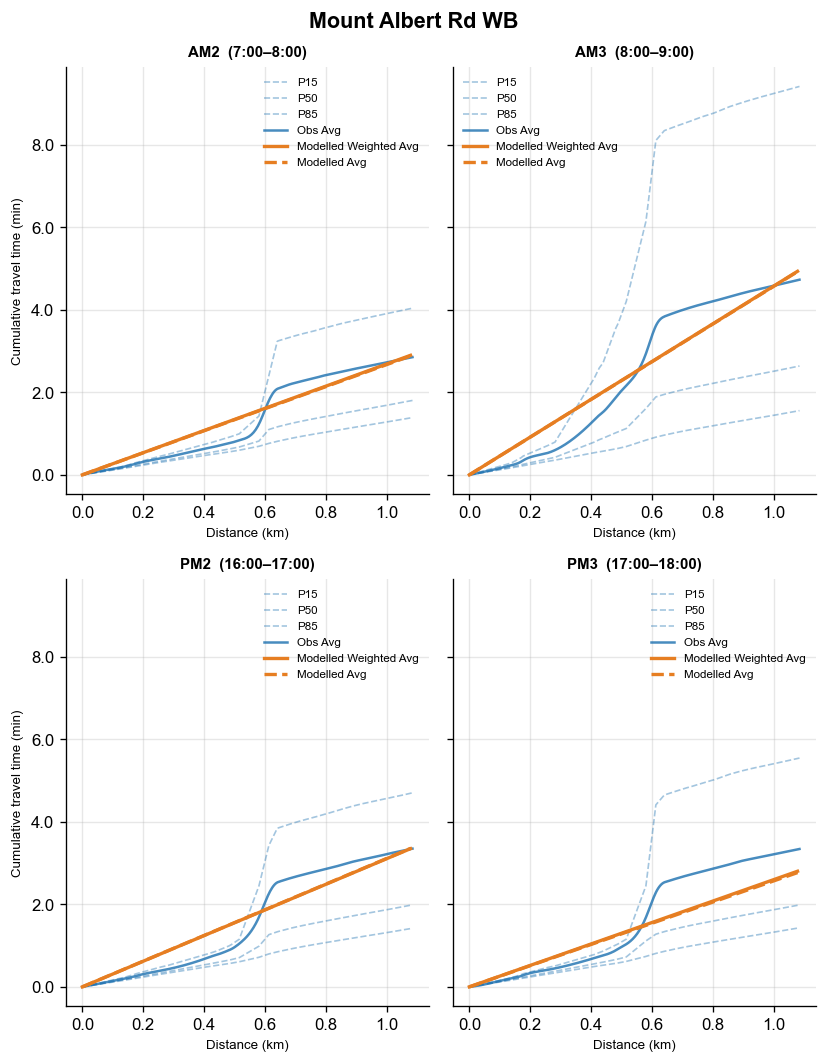

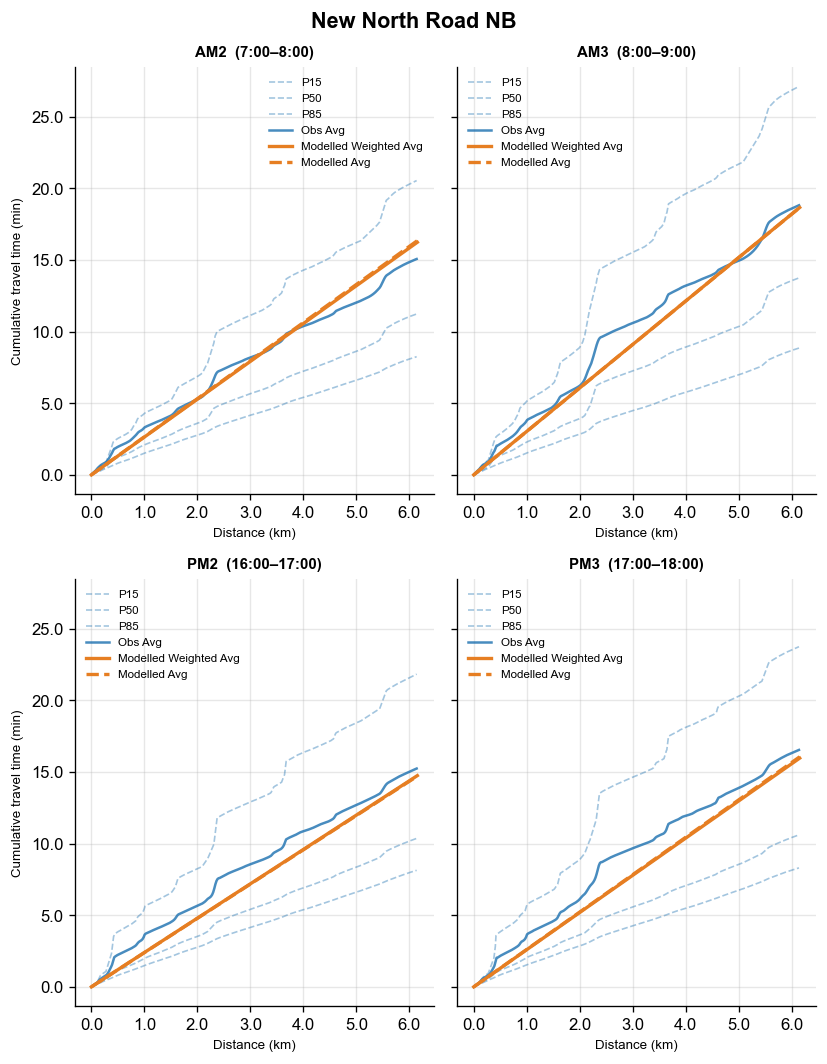

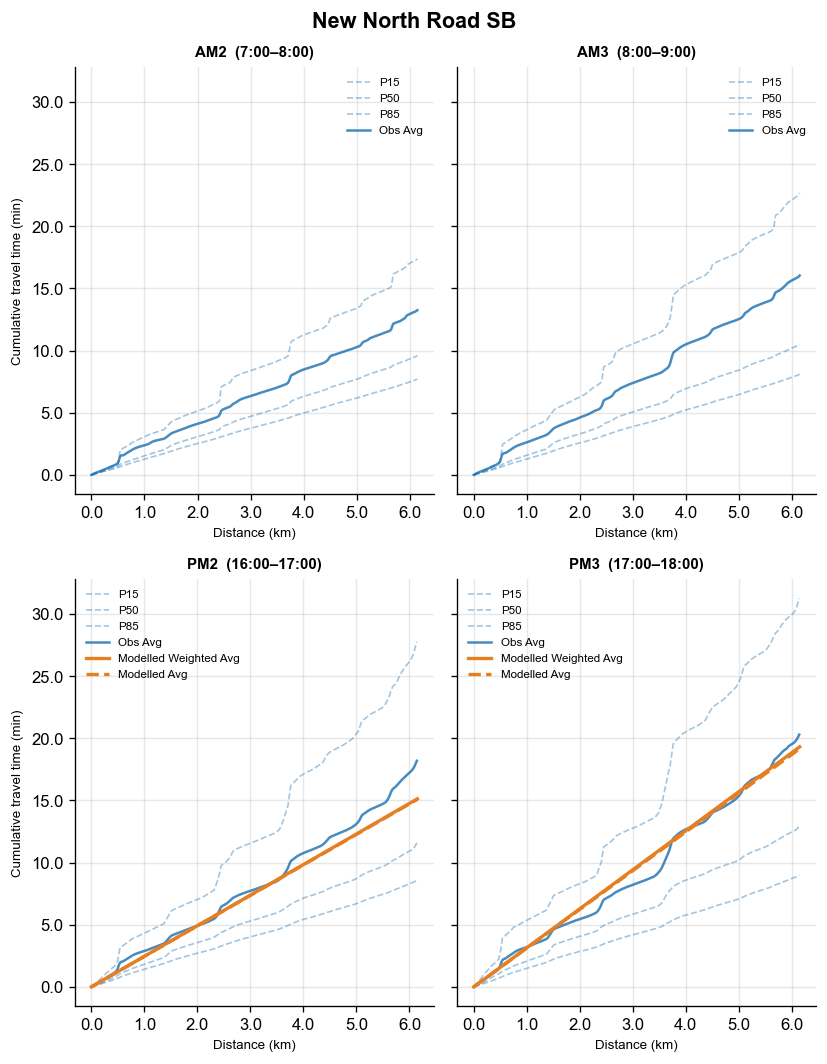

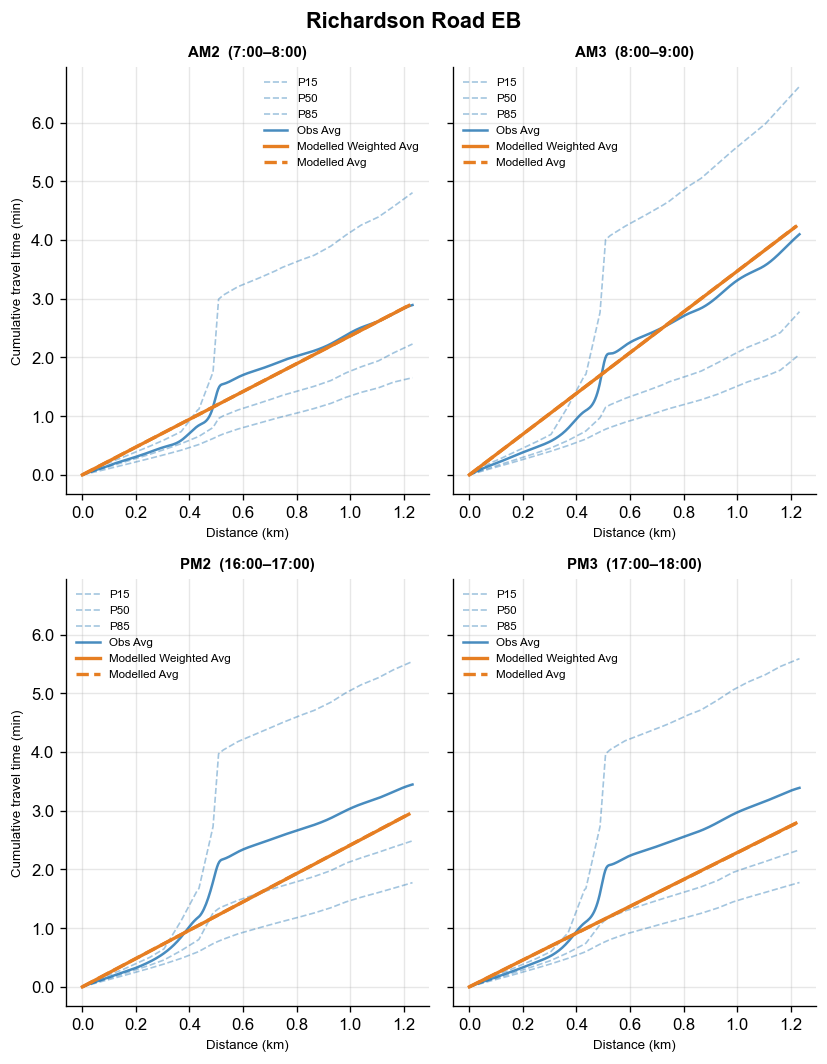

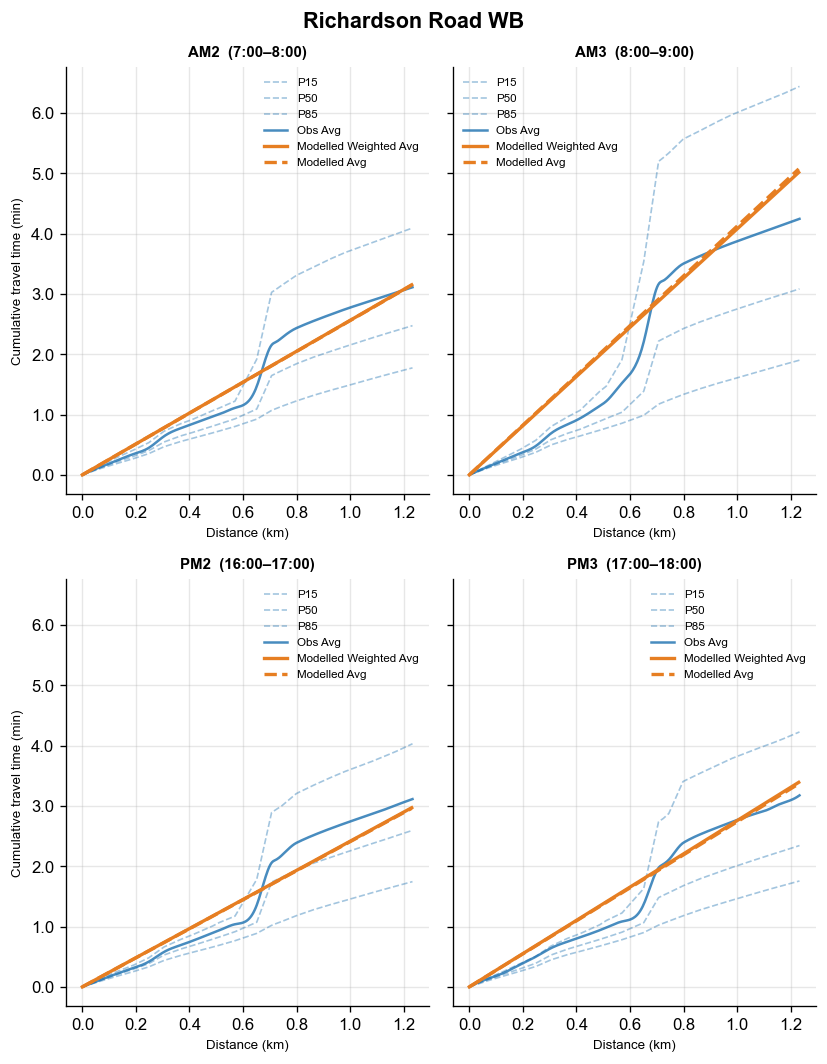

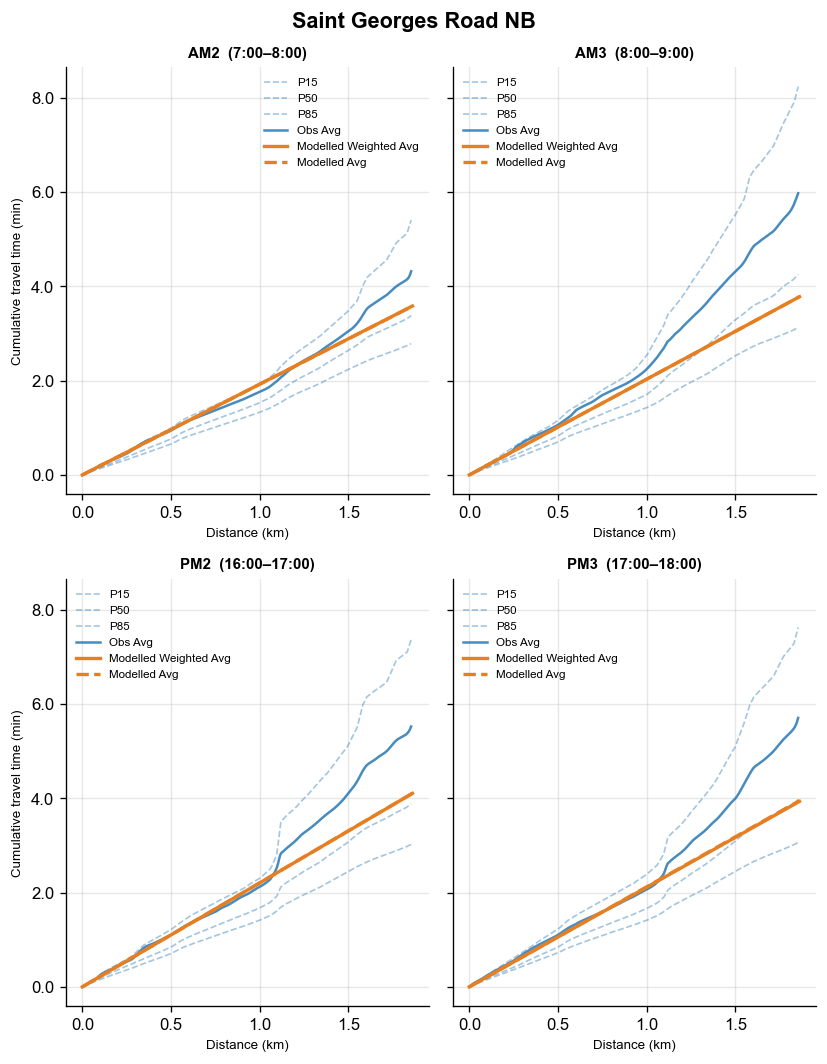

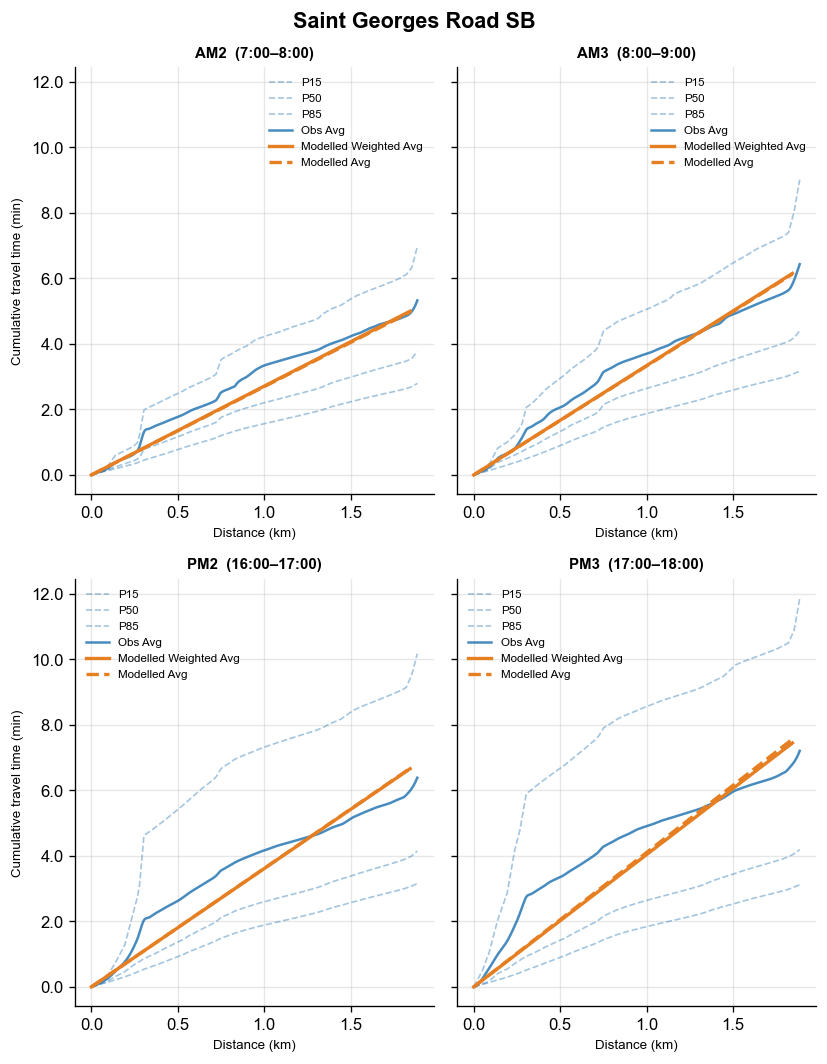

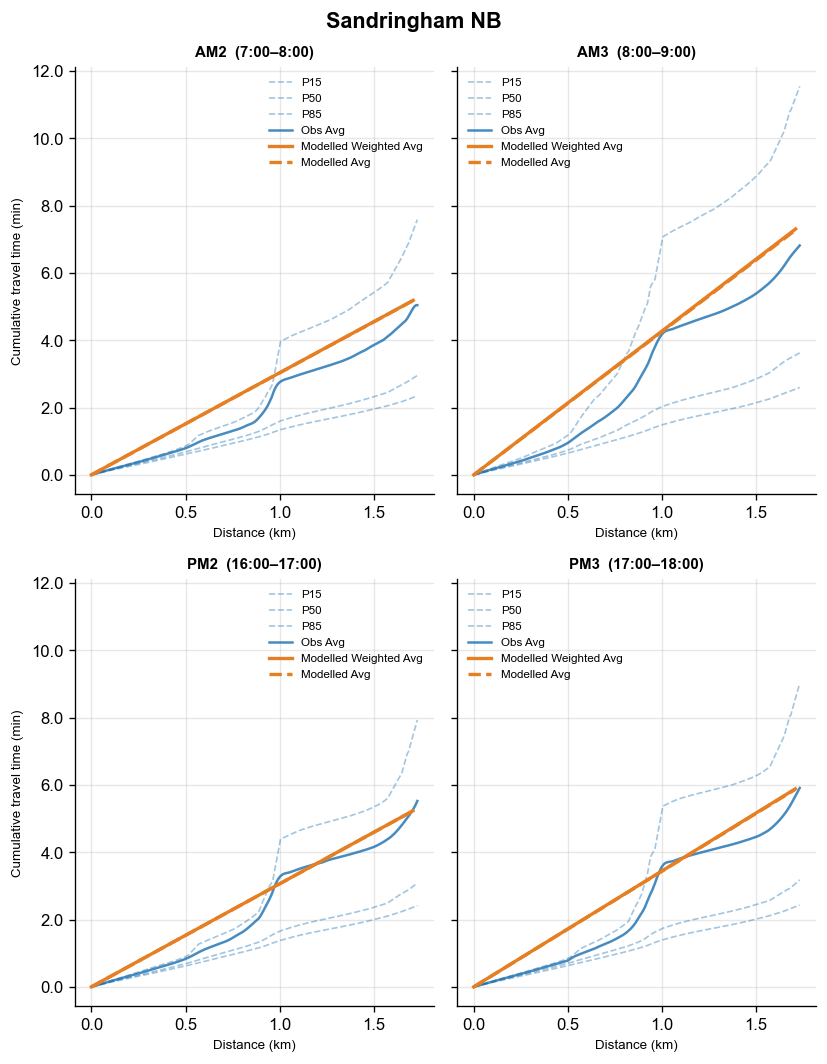

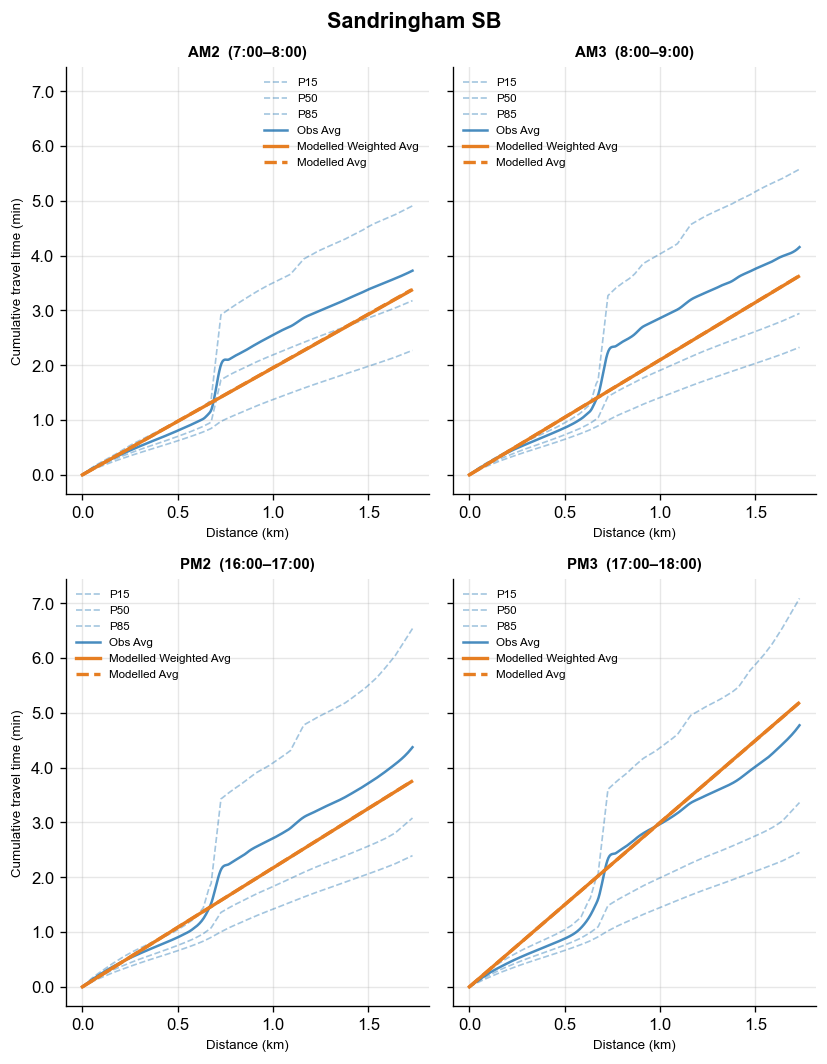

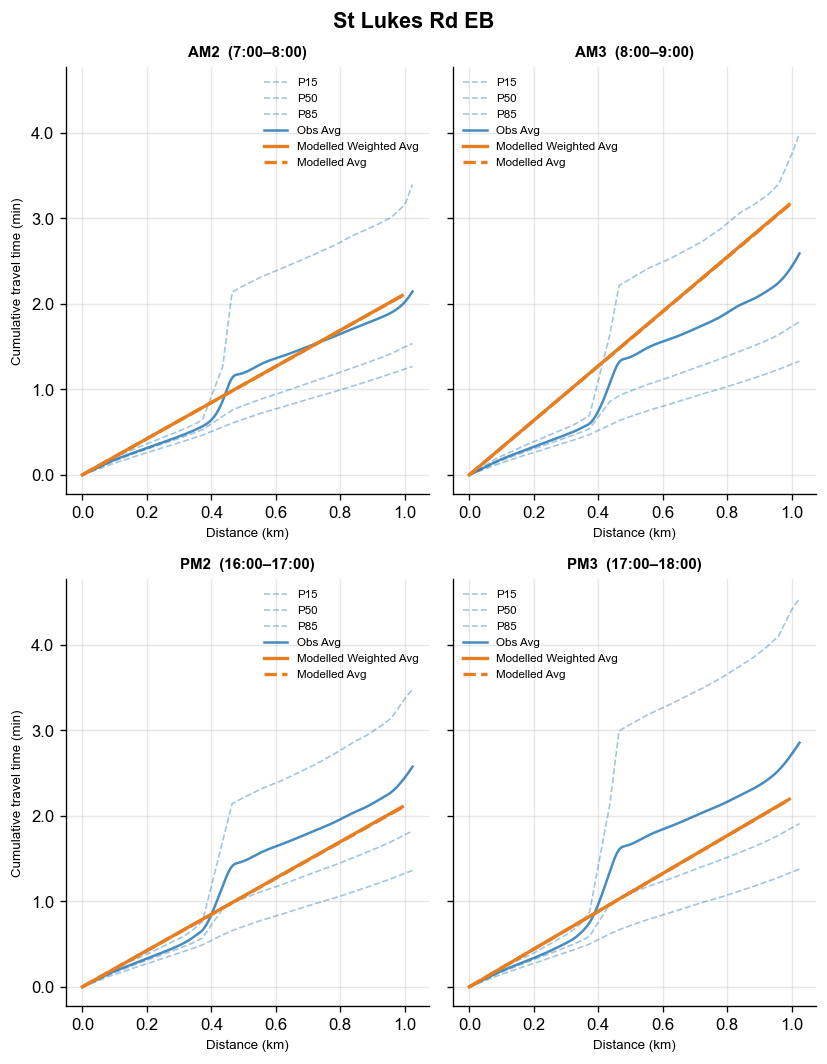

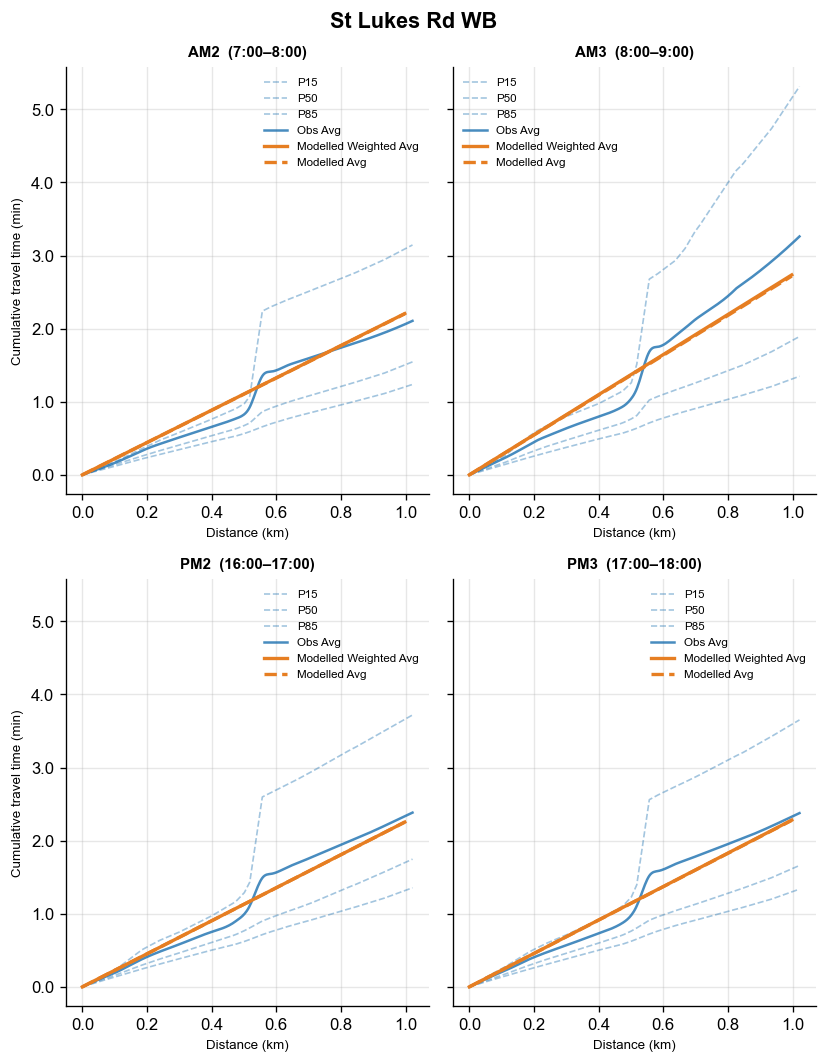

In [10]:
# One figure per route — one subplot per hour, arranged AM (top row) then PM (bottom row).
# TomTom: P15/P85 dashed blue, P50 smooth solid blue, Obs Avg smooth solid blue.
# Aimsun weighted avg: straight solid orange line.
# Aimsun simple avg:   straight dashed orange line.
# Obs hourly avg:      straight dashed blue line.

from scipy.interpolate import make_interp_spline

hour_order = output_hours_config["period"].tolist()
AM_HOURS = [h for h in hour_order if h.startswith("AM")]
PM_HOURS = [h for h in hour_order if h.startswith("PM")]

HOUR_LABELS = {
    row["period"]: f"{row['start_time'].hour}:{row['start_time'].minute:02d}–{row['end_time'].hour}:{row['end_time'].minute:02d}"
    for _, row in output_hours_config.iterrows()
}

wide = combined_df.pivot_table(
    index=["route", "hour", "cumulative_distance"],
    columns="scenario_name",
    values="average_ttime",
    aggfunc="mean",
).reset_index()
wide.columns.name = None

for col in ["obs_15th", "obs_50th", "obs_85th", "obs_avg"]:
    if col not in wide.columns:
        wide[col] = np.nan

P_COLOR      = "#1a6faf"
AIMSUN_COLOR = "#e67e22"

def smooth(x, y, n=300):
    mask = ~np.isnan(y)
    x, y = x[mask], y[mask]
    if len(x) < 4:
        return x, y
    spline = make_interp_spline(x, y, k=3)
    return np.linspace(x[0], x[-1], n), spline(np.linspace(x[0], x[-1], n))

n_cols = max(len(AM_HOURS), len(PM_HOURS))
n_rows = int(bool(AM_HOURS)) + int(bool(PM_HOURS))

for route in sorted(combined_df["route"].unique()):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 4.5 * n_rows),
                             sharey=True, squeeze=False)

    for row_idx, hour_group in enumerate([AM_HOURS, PM_HOURS]):
        for col_idx, hour in enumerate(hour_group):
            ax = axes[row_idx][col_idx]

            # ── TomTom observed curves ───────────────────────────────────
            d = wide[(wide["route"] == route) & (wide["hour"] == hour)].sort_values("cumulative_distance")
            x = d["cumulative_distance"].values / 1000

            if not d["obs_15th"].isna().all():
                ax.plot(x, d["obs_15th"], color=P_COLOR, linewidth=1,
                        linestyle="--", alpha=0.4, label="P15")
            if not d["obs_50th"].isna().all():
                ax.plot(x, d["obs_50th"], color=P_COLOR, linewidth=1,
                        linestyle="--", alpha=0.4, label="P50")
            if not d["obs_85th"].isna().all():
                ax.plot(x, d["obs_85th"], color=P_COLOR, linewidth=1,
                        linestyle="--", alpha=0.4, label="P85")
            if not d["obs_avg"].isna().all():
                xs, ys = smooth(x, d["obs_avg"].values)
                ax.plot(xs, ys, color=P_COLOR, linewidth=1.5,
                        alpha=0.8, label="Obs Avg")

            a = aimsun_weighted[
                (aimsun_weighted["route"] == route) & (aimsun_weighted["hour"] == hour)
            ]
            if not a.empty:
                dist_km      = a["route_dist_m"].values[0] / 1000
                w_ttime      = a["weighted_ttime_min"].values[0]
                s_ttime      = a["simple_ttime_min"].values[0]

                # ── Aimsun weighted avg — solid orange ───────────────────
                ax.plot([0, dist_km], [0, w_ttime], color=AIMSUN_COLOR,
                        linewidth=2, linestyle="-", label="Modelled Weighted Avg")

                # ── Aimsun simple avg — dashed orange ────────────────────
                ax.plot([0, dist_km], [0, s_ttime], color=AIMSUN_COLOR,
                        linewidth=2, linestyle="--", label="Modelled Avg")

            ax.set_title(f"{hour}  ({HOUR_LABELS.get(hour, '')})", fontsize=9, fontweight="bold")
            ax.set_xlabel("Distance (km)", fontsize=8)
            if col_idx == 0:
                ax.set_ylabel("Cumulative travel time (min)", fontsize=8)
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}"))
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}"))
            ax.legend(fontsize=7, frameon=False)

        for col_idx in range(len(hour_group), n_cols):
            axes[row_idx][col_idx].set_visible(False)

    fig.suptitle(route, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

In [11]:
# Hourly travel time comparison: observed (TomTom) vs Aimsun
# TomTom values are taken at the maximum cumulative distance (i.e. end of route).
# When multiple input files cover the same route/hour, values are averaged across files.

obs_end = (
    combined_df
    .sort_values("cumulative_distance", na_position="first")
    .groupby(["route", "hour", "scenario_name"])[["average_ttime"]]
    .last()
    .reset_index()
)

obs_wide = obs_end.pivot_table(
    index=["route", "hour"],
    columns="scenario_name",
    values="average_ttime",
    aggfunc="mean",
).reset_index()
obs_wide.columns.name = None

rename_map = {"obs_15th": "P15 (min)", "obs_50th": "P50 (min)",
              "obs_85th": "P85 (min)", "obs_avg":  "Obs Avg (min)"}
obs_wide = obs_wide.rename(columns={k: v for k, v in rename_map.items() if k in obs_wide.columns})

aimsun_summary = aimsun_weighted[["route", "hour", "weighted_ttime_min"]].rename(
    columns={"weighted_ttime_min": "Aimsun Avg (min)"}
).copy()

comparison = obs_wide.merge(aimsun_summary, on=["route", "hour"], how="outer")

if "Aimsun Avg (min)" in comparison.columns and "Obs Avg (min)" in comparison.columns:
    diff = comparison["Aimsun Avg (min)"] - comparison["Obs Avg (min)"]
    comparison["Diff Aimsun-Obs (min)"] = diff
    comparison["Speed Assessment"] = diff.apply(
        lambda v: np.nan if pd.isna(v) else ("Too Slow" if v > 0 else ("Too Fast" if v < 0 else "On Target"))
    )
    comparison["Within 15% of Obs Avg"] = (diff.abs() <= comparison["Obs Avg (min)"] * 0.15).map({True: "Pass", False: "Fail"})
    comparison["Within 1 min of Obs Avg"] = (diff.abs() <= 1.0).map({True: "Pass", False: "Fail"})
    comparison["Overall"] = ((comparison["Within 15% of Obs Avg"] == "Pass") | (comparison["Within 1 min of Obs Avg"] == "Pass")).map({True: "Pass", False: "Fail"})
    no_data = diff.isna()
    comparison.loc[no_data, ["Within 15% of Obs Avg", "Within 1 min of Obs Avg", "Overall"]] = np.nan

hour_order = output_hours_config["period"].tolist()
comparison["hour"] = pd.Categorical(comparison["hour"], categories=hour_order, ordered=True)
comparison = comparison.sort_values(["route", "hour"]).reset_index(drop=True)

# Build summary: exclude rows with no diff data
valid = comparison[comparison["Diff Aimsun-Obs (min)"].notna()]
summary = (
    valid.groupby("hour", observed=True)["Overall"]
    .apply(lambda x: round((x == "Pass").sum() / len(x) * 100, 1))
    .reset_index()
    .rename(columns={"Overall": "Pass %"})
)
summary["Pass Count"] = (
    valid.groupby("hour", observed=True)["Overall"]
    .apply(lambda x: (x == "Pass").sum())
    .values
)
summary["Total"] = (
    valid.groupby("hour", observed=True)["Overall"]
    .count()
    .values
)
summary = summary[["hour", "Pass Count", "Total", "Pass %"]]

COMPARISON_XLSX = 'outputs/travel_time_comparison.xlsx'
with pd.ExcelWriter(COMPARISON_XLSX, engine="openpyxl") as writer:
    comparison.to_excel(writer, sheet_name="Comparison", index=False)
    summary.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved {len(comparison)} rows -> {COMPARISON_XLSX}")
comparison

Saved 68 rows -> outputs/travel_time_comparison.xlsx


,route,hour,P15 (min),P50 (min),P85 (min),Obs Avg (min),Aimsun Avg (min),Diff Aimsun-Obs (min),Speed Assessment,Within 15% of Obs Avg,Within 1 min of Obs Avg,Overall
0,Blockhouse Bay Rd NB,AM2,1.040786,1.402524,5.186922,3.184833,2.863603,-0.321231,Too Fast,Pass,Pass,Pass
1,Blockhouse Bay Rd NB,AM3,1.280156,2.183314,9.808370,4.997667,3.324870,-1.672796,Too Fast,Fail,Fail,Fail
2,Blockhouse Bay Rd NB,PM2,1.044966,1.338394,3.690622,2.653500,2.071957,-0.581543,Too Fast,Fail,Pass,Pass
3,Blockhouse Bay Rd NB,PM3,1.053120,1.379455,4.887320,2.899667,2.215059,-0.684608,Too Fast,Fail,Pass,Pass
4,Great North Road EB,AM2,1.252160,1.658819,3.256120,2.373833,2.110839,-0.262995,Too Fast,Pass,Pass,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
63,St Lukes Rd EB,PM3,1.377688,1.908619,4.544394,2.856000,2.194796,-0.661204,Too Fast,Fail,Pass,Pass
64,St Lukes Rd WB,AM2,1.236808,1.545777,3.145052,2.106833,2.206249,0.099415,Too Slow,Pass,Pass,Pass
65,St Lukes Rd WB,AM3,1.348783,1.892252,5.313847,3.261667,2.735333,-0.526334,Too Fast,Fail,Pass,Pass
66,St Lukes Rd WB,PM2,1.355226,1.746787,3.719387,2.383667,2.254190,-0.129477,Too Fast,Pass,Pass,Pass


In [12]:
if OUTPUT_CSV:
    combined_df.to_csv(OUTPUT_CSV, index=False)
    print(f"Saved {len(combined_df)} rows -> {OUTPUT_CSV}")
else:
    print("OUTPUT_CSV is None — skipping save.")

Saved 14944 rows -> outputs/obs_travel_times.csv
